# TPU v6e 프로파일링과 최적화: JAX · JAX+Pallas · native Pallas

Colab **TPU v6e**에서 같은 BF16 모델의 전체 prefill/decode를 비교합니다.
소스를 내장했으므로 GitHub의 최신 상태나 별도 모델 다운로드에 의존하지 않습니다.
런타임 유형을 TPU v6e로 선택한 뒤 위에서부터 실행하세요.
두 독립 실행에서 전체 모델 성능 개선을 확인한 단계별 설정을 사용합니다.
`original_native`는 수정 전 커널과 attention을 함께 동결한 비교 대상입니다.

| 구현 | 실행 범위 |
|---|---|
| JAX | 원본 JAX decoder 전체를 JIT/XLA 컴파일 |
| JAX+Pallas | attention의 QK → causal softmax → PV를 직접 작성한 Pallas로 교체 |
| native Pallas | embedding, LayerNorm, 모든 GEMM, RoPE, head 배치, attention, residual, SwiGLU, KV 갱신 모두 Pallas |
| original native Pallas | 최적화 전 native 코드와 attention의 동결본; 같은 입력으로 재측정 |

native Pallas도 JAX의 배열·컴파일·호출 기능을 사용합니다. 모델 계산이 Pallas 밖으로
빠지지 않았는지는 StableHLO로 검사합니다. 모든 경로가 동일한 BF16 가중치·입력·cache를 공유합니다.


## 모델과 공정한 비교 조건

8층 decoder, D=2048, FFN=5632, query/KV heads=16, head_dim=128, vocabulary=32000.
LayerNorm·RoPE·causal attention·SwiGLU를 사용하는 무작위 가중치 모델입니다.

- **Prefill:** B=1, T=S=2048. 모든 prompt 위치의 logits를 계산합니다.
- **Decode:** B=8, T=1, S=2048. 마지막 cache 슬롯을 갱신하는 한 번의 forward입니다.
- 가중치·activation·KV·logits는 BF16, GEMM 누산과 정규화·softmax 내부 계산은 FP32입니다.
- 컴파일·입력 생성·host 전송·검증을 제외하고, warmup 후 호출마다 모든 출력의 완료를 기다립니다.
- 60개 표본의 측정 순서를 모든 경로 사이에서 순환·역전합니다. seed를 바꾼 별도 프로세스로 재확인합니다.
- cache donation은 사용하지 않습니다. 기존 cache 복사 비용도 시간에 포함됩니다.
- 여러 토큰을 연속 생성하는 serving/학습 성능을 측정하는 실험은 아닙니다.

정확도 기준은 실행 전에 고정합니다: FP32로 승격한 같은 BF16 가중치·입력의 원본 모델 대비
모든 logits/KV의 NRMSE ≤ 0.02, max_abs/RMS ≤ 0.20, RMS 분모 하한 1e-6.
Decode의 새 K/V를 별도로 검사하고 기존 cache prefix를 정확히 보존해야 합니다.
측정 후에는 원본 BF16 JAX와 다시 비교합니다. 반올림 차이를 허용하며 비트 단위 동일성은 요구하지 않습니다.


In [ ]:
import importlib.metadata as metadata
import subprocess
import sys
expected_versions = {"jax": "0.11.2", "jaxlib": "0.11.2", "libtpu": "0.0.48"}
try:
    installed = {name: metadata.version(name) for name in expected_versions}
except metadata.PackageNotFoundError:
    installed = {}
if installed != expected_versions:
    setup = subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "jax[tpu]==0.11.2", "libtpu==0.0.48"],
                           stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    print(setup.stdout)
    setup.check_returncode()
print({name: metadata.version(name) for name in ("jax", "jaxlib", "libtpu")})
# TPU는 아래 자식 프로세스에서만 초기화합니다. 이 notebook kernel에서 jax를 import하지 않습니다.


{'jax': '0.11.2', 'jaxlib': '0.11.2', 'libtpu': '0.0.48'}


## 실행 소스 준비

아래 압축 묶음은 저장소 구현의 정확한 snapshot이며 SHA-256을 확인한 뒤 풉니다.


In [ ]:
import base64, hashlib, json, os, zlib
from pathlib import Path
from datetime import datetime, timezone
BUNDLE_B64 = '...'
payload = zlib.decompress(base64.b64decode(BUNDLE_B64))
assert hashlib.sha256(payload).hexdigest() == '9413fce04033f32d9347f628b7a5d92618de38931f8120a508df452baa1149c8'
ROOT = Path("/content/pallas-opt") if Path("/content").exists() else Path.cwd() / "tpu-colab-run"
ROOT.mkdir(parents=True, exist_ok=True)
SOURCE_FILES = json.loads(payload)
for name, source in SOURCE_FILES.items():
    destination = ROOT / name
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(source)
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
PROFILE_ROOT = RESULTS / datetime.now(timezone.utc).strftime("profiles-after-%Y%m%dT%H%M%S")
print("Source SHA-256:", hashlib.sha256(payload).hexdigest())
print("Files:", *SOURCE_FILES, sep="\n")


Source SHA-256: 9413fce04033f32d9347f628b7a5d92618de38931f8120a508df452baa1149c8
Files:
llm_bench_tpu/__init__.py
llm_bench_tpu/__main__.py
llm_bench_tpu/config.py
llm_bench_tpu/kernels.py
llm_bench_tpu/metrics.py
llm_bench_tpu/model.py
llm_bench_tpu/native.py
llm_bench_tpu/profile_summary.py
llm_bench_tpu/profiling.py
llm_bench_tpu/runner.py
llm_bench_tpu/tune.py
llm_bench_tpu/frozen/__init__.py
llm_bench_tpu/frozen/kernels.py
llm_bench_tpu/frozen/model.py
llm_bench_tpu/frozen/native.py
llm_bench_tpu/configs/optimized-v6e.json
llm_roofline/__init__.py
llm_roofline/spec.py
llm_roofline/jax_llm.py
tests/test_llm_bench_tpu.py


## Pallas의 교체 범위 확인

아래 소스의 attention은 query tile마다 KV context 전체를 읽고,
QK와 softmax probability를 BF16로 변환해 VMEM에 유지합니다.
온라인 softmax/FlashAttention 구현은 아닙니다.
Native의 모든 모델 연산은 `native.py`의 Pallas kernel들로 구성됩니다.


In [ ]:
from IPython.display import Code, Markdown, display
display(Code(SOURCE_FILES["llm_bench_tpu/kernels.py"], language="python"))
display(Code(SOURCE_FILES["llm_bench_tpu/native.py"], language="python"))


"""Fused, full-context attention with explicit BF16 score/probability boundaries.

Q has already received RoPE and the head_dim**-0.5 scale. Each program
computes a query tile for one batch/head, keeping scores/probabilities in
VMEM. This is full-context tiled attention, not online FlashAttention.
"""
from __future__ import annotations

from functools import partial

import jax
import jax.numpy as jnp
from jax.experimental import pallas as pl
from jax.experimental.pallas import tpu as pltpu


def _attention_kernel(q_ref, k_ref, v_ref, out_ref, *, q_len, kv_len):
    scores = jax.lax.dot_general(
        q_ref[...], k_ref[...], (((1,), (1,)), ((), ())),
        preferred_element_type=jnp.float32, precision=jax.lax.Precision.DEFAULT,
    ).astype(q_ref.dtype).astype(jnp.float32)
    rows = pl.program_id(2) * q_ref.shape[0] + jnp.arange(q_ref.shape[0])
    cols = jnp.arange(kv_len)
    scores = jnp.where(cols[None, :] <= rows[:, None] + kv_len - q_len,
                       scores, -jnp.inf)
    numer = jnp.exp(scores - jnp.max(scores, axis=-1, keepdims=True))
    probs = (numer / jnp.sum(numer, axis=-1, keepdims=True)).astype(q_ref.dtype)
    out_ref[...] = jnp.matmul(
        probs, v_ref[...], preferred_element_type=jnp.float32, precision=jax.lax.Precision.DEFAULT,
    ).astype(out_ref.dtype)


def attention(q, k, v, *, block_q=128, decode_heads=1, interpret=False):
    """Causal prefill or fixed-context decode; supports grouped query heads.

Inputs/outputs: [batch, heads, sequence, head_dim]. Blocks span the entire
KV context, so this educational kernel targets the benchmark's 2048 slots.
It is not intended as a general long-context attention implementation.
"""
    batch, heads, q_len, head_dim = q.shape
    kv_heads, kv_len = k.shape[1:3]
    if k.shape != v.shape or k.shape[0] != batch or k.shape[-1] != head_dim:
        raise ValueError("K/V shape must match Q's batch and head dimension")
    if heads % kv_heads or q_len > kv_len:
        raise ValueError("query heads must be a multiple of KV heads; Q length <= KV length")
    if q.dtype != k.dtype or q.dtype != v.dtype:
        raise ValueError("Q, K, V must have the same dtype")
    bq = min(block_q, q_len)
    if bq <= 0 or q_len % bq:
        raise ValueError("block_q must be positive and divide the query length")
    groups = heads // kv_heads
    if q_len == 1 and decode_heads > 1:
        return _decode_grouped(q, k, v, decode_heads, interpret=interpret)
    return pl.pallas_call(
        partial(_attention_kernel, q_len=q_len, kv_len=kv_len),
        out_shape=jax.ShapeDtypeStruct(q.shape, q.dtype),
        grid=(batch, heads, q_len // bq),
        in_specs=[
            pl.BlockSpec((None, None, bq, head_dim), lambda b, h, i: (b, h, i, 0)),
            pl.BlockSpec((None, None, kv_len, head_dim), lambda b, h, i: (b, h // groups, 0, 0)),
            pl.BlockSpec((None, None, kv_len, head_dim), lambda b, h, i: (b, h // groups, 0, 0)),
        ],
        out_specs=pl.BlockSpec((None, None, bq, head_dim), lambda b, h, i: (b, h, i, 0)),
        compiler_params=pltpu.CompilerParams(dimension_semantics=("parallel", "parallel", "parallel")),
        interpret=interpret,
        name="same_model_pallas_attention",
    )(q, k, v)


def _decode_grouped(q, k, v, heads_per_block, *, interpret=False):
    """Load contiguous head groups together; preserve each head's BF16 softmax."""
    batch, heads, _, hdim = q.shape
    kv_heads, context = k.shape[1:3]
    groups = heads // kv_heads
    gh = min(heads_per_block, heads)
    if gh <= 0 or heads % gh or gh % groups:
        raise ValueError("decode head block must divide Q heads and contain whole KV groups")
    gkv = gh // groups

    def kernel(q_ref, k_ref, v_ref, out_ref):
        for h in range(gh):
            scores = jax.lax.dot_general(
                q_ref[h, :, :], k_ref[h // groups, :, :], (((1,), (1,)), ((), ())),
                preferred_element_type=jnp.float32, precision=jax.lax.Precision.DEFAULT,
           

"""All decoder compute in explicit Pallas TPU kernels.

JAX supplies arrays, compilation/dispatch, and metadata-only reshapes. No
JAX matmul, normalization, gather, activation or attention computes outside
the Pallas calls. Weights retain the reference's row-major shapes.
"""
from functools import partial
import math

import jax
import jax.numpy as jnp
from jax.experimental import pallas as pl
from jax.experimental.pallas import tpu as pltpu

from .kernels import attention
from .config import gemm_tile, phase_options


def _parallel(n):
    return pltpu.CompilerParams(dimension_semantics=("parallel",) * n)


def embed(tokens, table, *, interpret=False):
    m, d = math.prod(tokens.shape), table.shape[1]

    def kernel(tokens_ref, table_ref, out_ref):
        out_ref[...] = table_ref[...]

    out = pl.pallas_call(
        kernel, out_shape=jax.ShapeDtypeStruct((m, 1, d), table.dtype),
        grid_spec=pltpu.PrefetchScalarGridSpec(
            num_scalar_prefetch=1, grid=(m,),
            in_specs=[pl.BlockSpec((None, 1, d), lambda i, ids: (ids[i], 0, 0))],
            out_specs=pl.BlockSpec((None, 1, d), lambda i, ids: (i, 0, 0)),
        ),
        compiler_params=_parallel(1), interpret=interpret, name="native_embed",
    )(tokens.reshape(m), table.reshape(table.shape[0], 1, d))
    return out.reshape(*tokens.shape, d)


def layernorm(x, w, b, *, interpret=False):
    m, d = math.prod(x.shape[:-1]), x.shape[-1]
    bm = min(128, m)

    def kernel(x_ref, w_ref, b_ref, out_ref):
        xf = x_ref[...].astype(jnp.float32)
        mean = jnp.sum(xf, axis=1, keepdims=True) / d
        centered = xf - mean
        var = jnp.sum(centered * centered, axis=1, keepdims=True) / d
        y = centered * jax.lax.rsqrt(var + 1e-5)
        out_ref[...] = (y * w_ref[...].astype(jnp.float32)[None, :]
                        + b_ref[...].astype(jnp.float32)[None, :]).astype(x.dtype)

    bs = pl.BlockSpec((bm, d), lambda i: (i, 0))
    out = pl.pallas_call(
        kernel, out_shape=jax.ShapeDtypeStruct((m, d), x.dtype), grid=(m // bm,),
        in_specs=[bs, pl.BlockSpec((d,), lambda i: (0,)), pl.BlockSpec((d,), lambda i: (0,))],
        out_specs=bs, compiler_params=_parallel(1), interpret=interpret, name="native_layernorm",
    )(x.reshape(m, d), w, b)
    return out.reshape(x.shape)


def _matmul_kernel(x_ref, w_ref, out_ref, acc_ref, *, steps):
    @pl.when(pl.program_id(2) == 0)
    def init():
        acc_ref[...] = jnp.zeros(acc_ref.shape, jnp.float32)

    acc_ref[...] += jnp.matmul(x_ref[...], w_ref[...], preferred_element_type=jnp.float32,
                              precision=jax.lax.Precision.DEFAULT)

    @pl.when(pl.program_id(2) == steps - 1)
    def finish():
        out_ref[...] = acc_ref[...].astype(out_ref.dtype)


def linear(x, w, *, tiles=None, interpret=False):
    m, k, n = math.prod(x.shape[:-1]), w.shape[0], w.shape[1]
    bm, bk, bn = gemm_tile(m, k, n, tiles)
    if x.shape[-1] != k or m % bm or k % bk or n % bn:
        raise ValueError(f"unsupported GEMM shape: {(m, k, n)}")
    out = pl.pallas_call(
        partial(_matmul_kernel, steps=k // bk),
        out_shape=jax.ShapeDtypeStruct((m, n), x.dtype), grid=(m // bm, n // bn, k // bk),
        in_specs=[pl.BlockSpec((bm, bk), lambda i, j, r: (i, r)),
                  pl.BlockSpec((bk, bn), lambda i, j, r: (r, j))],
        out_specs=pl.BlockSpec((bm, bn), lambda i, j, r: (i, j)),
        scratch_shapes=[pltpu.VMEM((bm, bn), jnp.float32)],
        compiler_params=pltpu.CompilerParams(dimension_semantics=("parallel", "parallel", "arbitrary")),
        interpret=interpret, name="native_gemm",
    )(x.reshape(m, k), w)
    return out.reshape(*x.shape[:-1], n)


def _rope_kernel(x_ref, cos_ref, sin_ref, out_ref, *, scale):
    h = x_ref.shape[-1]
    x = x_ref[...].astype(jnp.float32)
    c = (cos_ref[...].astype(jnp.float32) * scale).astype(x_ref.dtype).astype(jnp.float32)
    s = (sin_ref[...].astype(jnp.float32) * scale).astype(x_ref.dtype).astype(jnp.float

In [ ]:
def run_job(arguments, log_name, extra_env=None):
    environment = dict(os.environ, JAX_PLATFORMS="tpu", PYTHONUNBUFFERED="1")
    environment.update(extra_env or {})
    with (RESULTS / log_name).open("w") as log:
        job = subprocess.Popen([sys.executable, "-u", *arguments], cwd=ROOT, env=environment,
                               stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
        for line in job.stdout:
            print(line, end="", flush=True)
            log.write(line)
            log.flush()
        exit_code = job.wait()
    assert exit_code == 0, f"Process failed: see {RESULTS / log_name}"

def benchmark(name, seed, *flags):
    run_job(["-m", "llm_bench_tpu", "--seed", str(seed), "--out", str(RESULTS / f"{name}.json"),
             "--tuning-config", str(ROOT / "llm_bench_tpu/configs/optimized-v6e.json"),
             "--backends", "jax,hybrid,native,original_native",
             "--hlo-dir", str(RESULTS / f"hlo-{name}"), *flags], f"{name}.log")
    result = json.loads((RESULTS / f"{name}.json").read_text())
    assert result["complete"] and result["status"] == "ok"
    return result


## 작은 모델 및 TPU 경계조건 검사

작은 모델의 시간은 최종 성능표에 포함하지 않습니다.


In [ ]:
smoke = benchmark("smoke", 123, "--smoke", "--samples", "3")
run_job(["-m", "unittest", "discover", "-s", "tests", "-p", "test_llm_bench_tpu.py", "-v"],
        "device-tests.log", {"RUN_TPU_PALLAS_TESTS": "1"})


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:90: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")


  warnings.warn(


RUNTIME {"python": "3.13.15", "packages": {"jax": "0.11.2", "jaxlib": "0.11.2", "libtpu": "0.0.48", "numpy": "2.1.3"}, "devices": [{"kind": "TPU v6 lite", "platform": "tpu", "memory": {"num_allocs": 2, "bytes_in_use": 54272, "peak_bytes_in_use": 54272, "largest_alloc_size": 52736, "bytes_limit": 33546042880, "bytes_reserved": 0, "peak_bytes_reserved": 0, "bytes_reservable_limit": 33546042880, "largest_free_block_bytes": 33545988608}}], "default_matmul_precision": "highest (FP32 reference); timed inputs/outputs are BF16"}


PHASE prefill


COMPILE prefill jax


...

test_profile_aggregation_does_not_double_count_nested_or_overlapped_ops (test_llm_bench_tpu.ValidationTests.test_profile_aggregation_does_not_double_count_nested_or_overlapped_ops) ... ok


test_tiles_clamp_small_shapes_and_reject_empty_or_oversized_grids (test_llm_bench_tpu.ValidationTests.test_tiles_clamp_small_shapes_and_reject_empty_or_oversized_grids) ... ok


----------------------------------------------------------------------


Ran 12 tests in 12.755s


OK


## 전체 모델 측정 1

동일한 장치·같은 가중치 배열로 세 구현을 실행합니다. 컴파일 시간은 별도 기록합니다.


In [ ]:
primary = benchmark("run1", 123, "--profile-dir", str(PROFILE_ROOT), "--profile-steps", "20")


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:90: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")


  warnings.warn(


RUNTIME {"python": "3.13.15", "packages": {"jax": "0.11.2", "jaxlib": "0.11.2", "libtpu": "0.0.48", "numpy": "2.1.3"}, "devices": [{"kind": "TPU v6 lite", "platform": "tpu", "memory": {"num_allocs": 2, "bytes_in_use": 54272, "peak_bytes_in_use": 54272, "largest_alloc_size": 52736, "bytes_limit": 33546042880, "bytes_reserved": 0, "peak_bytes_reserved": 0, "bytes_reservable_limit": 33546042880, "largest_free_block_bytes": 33545988608}}], "default_matmul_precision": "highest (FP32 reference); timed inputs/outputs are BF16"}


PHASE prefill


COMPILE prefill jax


...

PROFILE decode jax


PROFILE decode hybrid


PROFILE decode native


PROFILE decode original_native


TPU_THREE_WAY_COMPLETE


## 전체 모델 측정 2

새 가중치·입력(seed 321), 반대 컴파일 순서, 별도 프로세스로 확인합니다.


In [ ]:
confirmation = benchmark("run2", 321, "--reverse")


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:90: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")


  warnings.warn(


RUNTIME {"python": "3.13.15", "packages": {"jax": "0.11.2", "jaxlib": "0.11.2", "libtpu": "0.0.48", "numpy": "2.1.3"}, "devices": [{"kind": "TPU v6 lite", "platform": "tpu", "memory": {"num_allocs": 2, "bytes_in_use": 54272, "peak_bytes_in_use": 54272, "largest_alloc_size": 52736, "bytes_limit": 33546042880, "bytes_reserved": 0, "peak_bytes_reserved": 0, "bytes_reservable_limit": 33546042880, "largest_free_block_bytes": 33545988608}}], "default_matmul_precision": "highest (FP32 reference); timed inputs/outputs are BF16"}


PHASE prefill


COMPILE prefill original_native


...

TIME decode original_native 10.3526595


TIME decode native 3.5021649999999998


TIME decode hybrid 3.1018844999999997


TIME decode jax 2.9206105


TPU_THREE_WAY_COMPLETE


## 실측 결과

배속은 **같은 실행의 JAX 중앙값 ÷ 각 구현 중앙값**입니다. 1보다 크면 빠릅니다.


In [ ]:
labels = {"jax": "JAX", "hybrid": "JAX+Pallas", "native": "native Pallas (optimized)", "original_native": "native Pallas (original)"}
lines = ["| Seed | 단계 | 구현 | p50 ms | p95 ms | JAX 대비 배속 | 컴파일 s |",
         "|---|---|---|---:|---:|---:|---:|"]
for result in (primary, confirmation):
    for phase, data in result["phases"].items():
        for backend, label in labels.items():
            row = data["backends"][backend]
            latency = row["latency"]
            assert row["accuracy_fp32"]["passed"] and row["post_timing_vs_jax"]["passed"]
            lines.append(f"| {result['arguments']['seed']} | {phase} | {label} | {latency['median_ms']:.4f} | "
                         f"{latency['p95_ms']:.4f} | {row['speedup_vs_jax']:.3f}× | {row['compile_s']:.2f} |")
display(Markdown("\n".join(lines)))
print("실제 런타임:", primary["runtime"])
print("매개변수 수:", f"{primary['parameter_count']:,}")


| Seed | 단계 | 구현 | p50 ms | p95 ms | JAX 대비 배속 | 컴파일 s |
|---|---|---|---:|---:|---:|---:|
| 123 | prefill | JAX | 9.4930 | 9.5398 | 1.000× | 3.92 |
| 123 | prefill | JAX+Pallas | 5.1420 | 5.1801 | 1.846× | 3.44 |
| 123 | prefill | native Pallas (optimized) | 6.8587 | 6.8983 | 1.384× | 1.71 |
| 123 | prefill | native Pallas (original) | 11.7080 | 11.7506 | 0.811× | 0.47 |
| 123 | decode | JAX | 2.9496 | 3.3399 | 1.000× | 1.56 |
| 123 | decode | JAX+Pallas | 3.0803 | 3.1367 | 0.958× | 1.55 |
| 123 | decode | native Pallas (optimized) | 3.4392 | 3.4808 | 0.858× | 0.56 |
| 123 | decode | native Pallas (original) | 10.3331 | 10.3611 | 0.285× | 0.35 |
| 321 | prefill | JAX | 9.4793 | 9.5357 | 1.000× | 3.86 |
| 321 | prefill | JAX+Pallas | 5.1480 | 5.1859 | 1.841× | 3.49 |
| 321 | prefill | native Pallas (optimized) | 6.8673 | 6.9086 | 1.380× | 1.74 |
| 321 | prefill | native Pallas (original) | 11.7298 | 11.7746 | 0.808× | 0.48 |
| 321 | decode | JAX | 2.9206 | 3.0028 | 1.000× | 1.53 |
| 321 | decode | JAX+Pallas | 3.1019 | 3.4695 | 0.942× | 1.48 |
| 321 | decode | native Pallas (optimized) | 3.5022 | 3.9191 | 0.834× | 0.61 |
| 321 | decode | native Pallas (original) | 10.3527 | 10.4033 | 0.282× | 0.35 |

실제 런타임: {'python': '3.13.15', 'packages': {'jax': '0.11.2', 'jaxlib': '0.11.2', 'libtpu': '0.0.48', 'numpy': '2.1.3'}, 'devices': [{'kind': 'TPU v6 lite', 'platform': 'tpu', 'memory': {'num_allocs': 2, 'bytes_in_use': 54272, 'peak_bytes_in_use': 54272, 'largest_alloc_size': 52736, 'bytes_limit': 33546042880, 'bytes_reserved': 0, 'peak_bytes_reserved': 0, 'bytes_reservable_limit': 33546042880, 'largest_free_block_bytes': 33545988608}}], 'default_matmul_precision': 'highest (FP32 reference); timed inputs/outputs are BF16'}
매개변수 수: 542,183,424


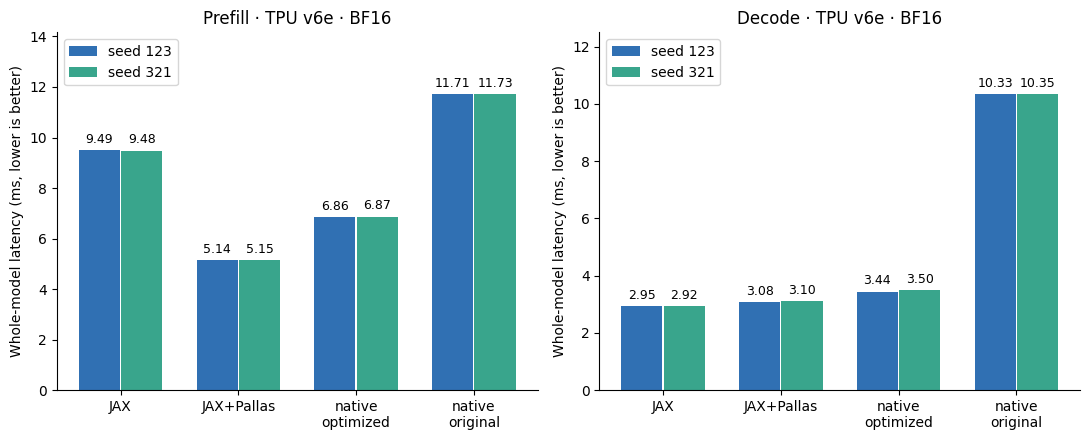

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, phase in zip(axes, ("prefill", "decode")):
    x = np.arange(len(labels))
    for offset, result, color in ((-.18, primary, "#3070b3"), (.18, confirmation, "#39a58c")):
        values = [result["phases"][phase]["backends"][b]["latency"]["median_ms"] for b in labels]
        bars = ax.bar(x + offset, values, .35, color=color, label=f"seed {result['arguments']['seed']}")
        ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=3)
    ax.set_xticks(x, ["JAX", "JAX+Pallas", "native\noptimized", "native\noriginal"])
    ax.set_ylabel("Whole-model latency (ms, lower is better)")
    ax.set_title(phase.capitalize() + " · TPU v6e · BF16")
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "comparison.png", dpi=160)
fig.savefig(RESULTS / "comparison.svg")
plt.show()


In [ ]:
lines = ["| 단계 | 구현 | Pallas 호출 수 | 최대 FP32 NRMSE (두 실행) |",
         "|---|---|---:|---:|"]
for phase in ("prefill", "decode"):
    for backend, label in labels.items():
        rows = [r["phases"][phase]["backends"][backend] for r in (primary, confirmation)]
        lines.append(f"| {phase} | {label} | {rows[0]['hlo_audit']['pallas_calls']} | "
                     f"{max(r['accuracy_fp32']['max_nrmse'] for r in rows):.6f} |")
display(Markdown("\n".join(lines)))
for phase in ("prefill", "decode"):
    for backend in ("hybrid", "native"):
        speedups = [r["phases"][phase]["backends"][backend]["speedup_vs_jax"] for r in (primary, confirmation)]
        print(f"{phase} {labels[backend]}: {min(speedups):.3f}–{max(speedups):.3f}× vs same-run JAX")


| 단계 | 구현 | Pallas 호출 수 | 최대 FP32 NRMSE (두 실행) |
|---|---|---:|---:|
| prefill | JAX | 0 | 0.010216 |
| prefill | JAX+Pallas | 8 | 0.010218 |
| prefill | native Pallas (optimized) | 115 | 0.011003 |
| prefill | native Pallas (original) | 139 | 0.011000 |
| decode | JAX | 0 | 0.010394 |
| decode | JAX+Pallas | 8 | 0.010342 |
| decode | native Pallas (optimized) | 131 | 0.011415 |
| decode | native Pallas (original) | 155 | 0.011425 |

prefill JAX+Pallas: 1.841–1.846× vs same-run JAX
prefill native Pallas (optimized): 1.380–1.384× vs same-run JAX
decode JAX+Pallas: 0.942–0.958× vs same-run JAX
decode native Pallas (optimized): 0.834–0.858× vs same-run JAX


## 장치 프로파일: 원인과 개선의 확인

점수 측정이 끝난 뒤, 컴파일·warmup이 완료된 모델을 경로별로 20회 실행해
XPlane과 Perfetto를 저장했습니다. 아래는 실제 TPU `XLA Ops` 트랙의 시간입니다.
중첩된 커널과 DMA/비동기 트랙의 시간을 더하지 않고, 겹치는 구간을 한 번만 집계합니다.
장치 시간에는 호스트 호출·동기화 비용이 포함되지 않으므로 위 전체 지연과 구분합니다.
일반 XLA 연산의 분류는 프로파일러가 제공한 분류를 그대로 사용합니다.
`convolution fusion`을 CNN 연산으로 해석하지 않습니다.

최적화 전 최초 프로파일에서 native decode는 장치 시간 9.84ms 중 KV 갱신이
7.42ms(약 75%)였고, GEMM은 0.87ms였습니다. Prefill은 GEMM 5.33ms가 가장 컸습니다.
이는 2026-10-05의 초기 측정이며, 아래 표는 **이 노트북 실행에서 재측정한 결과**입니다.
설정 파일을 생략하면 원본 설정으로 동작합니다. 모든 커널이 모든 shape에서 빠르다는 뜻은 아닙니다.
[TPU 블록 제약](https://docs.jax.dev/en/latest/pallas/tpu/details.html),
[TPU GEMM](https://docs.jax.dev/en/latest/pallas/tpu/matmul.html),
[프로파일 수집 API](https://docs.jax.dev/en/latest/_autosummary/jax.profiler.trace.html).


In [ ]:
run_job(["-m", "llm_bench_tpu.profile_summary", str(PROFILE_ROOT),
         "--out", str(RESULTS / "profile-after.json")], "profile-summary.log")
profiles = json.loads((RESULTS / "profile-after.json").read_text())
lines = ["| 단계 | 구현 | 장치 평균 ms | KV 갱신 ms | GEMM ms | Attention ms |",
         "|---|---|---:|---:|---:|---:|"]
for phase in ("prefill", "decode"):
    for backend in ("original_native", "native"):
        row = profiles[f"{phase}-{backend}"]
        assert row["device_events_verified"] and row["steps"] == 20
        category_ms = lambda c: row["categories"].get(c, {}).get("exclusive_ms_per_step", 0)
        lines.append(f"| {phase} | {labels[backend]} | {row['device_module_mean_ms']:.3f} | "
                     f"{category_ms('KV write'):.3f} | {category_ms('GEMM'):.3f} | {category_ms('Attention'):.3f} |")
display(Markdown("\n".join(lines)))
print("실측으로 선택한 설정:", json.dumps(primary["tuning_config"], indent=2))


decode-hybrid {"file": "/content/pallas-opt/results/profiles-after-20261004T173750/decode-hybrid/plugins/profile/2026_10_04_17_40_43/perfetto_trace.json.gz", "device_events_verified": true, "device": "/device:TPU:0", "steps": 20, "device_module_mean_ms": 2.7051727656, "device_module_median_ms": 2.641960742, "categories": {"Attention": {"exclusive_ms_per_step": 0.9431608555999988, "events_per_step": 8.0}, "XLA/data formatting": {"exclusive_ms_per_step": 0.8031358357000028, "events_per_step": 56.0}, "XLA/convolution fusion": {"exclusive_ms_per_step": 0.5301327262000008, "events_per_step": 57.0}, "XLA/async-done": {"exclusive_ms_per_step": 0.21192952230009224, "events_per_step": 282.0}, "XLA/copy-done": {"exclusive_ms_per_step": 0.13827350330001847, "events_per_step": 47.0}, "XLA/dynamic-update-slice": {"exclusive_ms_per_step": 0.05914720310000075, "events_per_step": 16.0}, "XLA/loop fusion": {"exclusive_ms_per_step": 0.007327640700008942, "events_per_step": 88.0}, "XLA/custom fusion": {"

decode-jax {"file": "/content/pallas-opt/results/profiles-after-20261004T173750/decode-jax/plugins/profile/2026_10_04_17_40_41/perfetto_trace.json.gz", "device_events_verified": true, "device": "/device:TPU:0", "steps": 20, "device_module_mean_ms": 2.6607687617, "device_module_median_ms": 2.7103269529999996, "categories": {"XLA/loop fusion": {"exclusive_ms_per_step": 0.8044286983000115, "events_per_step": 104.0}, "XLA/data formatting": {"exclusive_ms_per_step": 0.7535116523000007, "events_per_step": 56.0}, "XLA/convolution fusion": {"exclusive_ms_per_step": 0.5222847109000066, "events_per_step": 57.0}, "XLA/async-done": {"exclusive_ms_per_step": 0.41924087650008196, "events_per_step": 306.0}, "XLA/copy-done": {"exclusive_ms_per_step": 0.08183274580001634, "events_per_step": 48.0}, "XLA/dynamic-update-slice": {"exclusive_ms_per_step": 0.06390267979999543, "events_per_step": 16.0}, "XLA/custom fusion": {"exclusive_ms_per_step": 0.004196293000000333, "events_per_step": 1.0}, "XLA/output f

decode-native {"file": "/content/pallas-opt/results/profiles-after-20261004T173750/decode-native/plugins/profile/2026_10_04_17_40_46/perfetto_trace.json.gz", "device_events_verified": true, "device": "/device:TPU:0", "steps": 20, "device_module_mean_ms": 3.0176208319999995, "device_module_median_ms": 2.985806914, "categories": {"KV write": {"exclusive_ms_per_step": 1.5048028439000025, "events_per_step": 16.0}, "Attention": {"exclusive_ms_per_step": 0.6664055157000006, "events_per_step": 8.0}, "GEMM": {"exclusive_ms_per_step": 0.4348328953999929, "events_per_step": 57.0}, "XLA/data formatting": {"exclusive_ms_per_step": 0.2992983906000007, "events_per_step": 10.0}, "XLA/async-done": {"exclusive_ms_per_step": 0.04862393660008402, "events_per_step": 156.0}, "XLA/copy-done": {"exclusive_ms_per_step": 0.02080842940001967, "events_per_step": 47.0}, "RoPE/layout": {"exclusive_ms_per_step": 0.016803839800002426, "events_per_step": 8.0}, "Embedding": {"exclusive_ms_per_step": 0.0096306914000002

decode-original_native {"file": "/content/pallas-opt/results/profiles-after-20261004T173750/decode-original_native/plugins/profile/2026_10_04_17_40_48/perfetto_trace.json.gz", "device_events_verified": true, "device": "/device:TPU:0", "steps": 20, "device_module_mean_ms": 9.8421663828, "device_module_median_ms": 9.842490077999999, "categories": {"KV write": {"exclusive_ms_per_step": 7.4204096599999945, "events_per_step": 16.0}, "Attention": {"exclusive_ms_per_step": 0.8891144845000042, "events_per_step": 8.0}, "GEMM": {"exclusive_ms_per_step": 0.8713692262999814, "events_per_step": 57.0}, "RoPE/layout": {"exclusive_ms_per_step": 0.35144262489998246, "events_per_step": 32.0}, "XLA/data formatting": {"exclusive_ms_per_step": 0.29428384760001336, "events_per_step": 34.0}, "LayerNorm": {"exclusive_ms_per_step": 0.003709000000004198, "events_per_step": 17.0}, "Embedding": {"exclusive_ms_per_step": 0.002907488299999204, "events_per_step": 1.0}, "SwiGLU": {"exclusive_ms_per_step": 0.002876433

prefill-hybrid {"file": "/content/pallas-opt/results/profiles-after-20261004T173750/prefill-hybrid/plugins/profile/2026_10_04_17_39_14/perfetto_trace.json.gz", "device_events_verified": true, "device": "/device:TPU:0", "steps": 20, "device_module_mean_ms": 4.6897377187, "device_module_median_ms": 4.689761133, "categories": {"XLA/convolution fusion": {"exclusive_ms_per_step": 2.7712165159999884, "events_per_step": 57.0}, "Attention": {"exclusive_ms_per_step": 1.239951206999999, "events_per_step": 8.0}, "XLA/data formatting": {"exclusive_ms_per_step": 0.34230765329999546, "events_per_step": 37.0}, "XLA/loop fusion": {"exclusive_ms_per_step": 0.25342323470002126, "events_per_step": 87.0}, "XLA/custom fusion": {"exclusive_ms_per_step": 0.039735812500000973, "events_per_step": 1.0}, "XLA/non-fusion elementwise": {"exclusive_ms_per_step": 0.03375105030000113, "events_per_step": 34.0}, "XLA/async-start": {"exclusive_ms_per_step": 0.0016486713001049793, "events_per_step": 232.0}, "XLA/async-do

prefill-jax {"file": "/content/pallas-opt/results/profiles-after-20261004T173750/prefill-jax/plugins/profile/2026_10_04_17_39_12/perfetto_trace.json.gz", "device_events_verified": true, "device": "/device:TPU:0", "steps": 20, "device_module_mean_ms": 9.016427168, "device_module_median_ms": 9.016618789, "categories": {"XLA/convolution fusion": {"exclusive_ms_per_step": 5.59473859729999, "events_per_step": 73.0}, "XLA/output fusion": {"exclusive_ms_per_step": 2.979426785100001, "events_per_step": 8.0}, "XLA/data formatting": {"exclusive_ms_per_step": 0.2580932891000077, "events_per_step": 34.0}, "XLA/loop fusion": {"exclusive_ms_per_step": 0.11633743779999205, "events_per_step": 79.0}, "XLA/custom fusion": {"exclusive_ms_per_step": 0.039782035200001335, "events_per_step": 1.0}, "XLA/copy-done": {"exclusive_ms_per_step": 0.014333445200213827, "events_per_step": 113.0}, "XLA/async-done": {"exclusive_ms_per_step": 0.007427675800167526, "events_per_step": 90.0}, "XLA/copy-start": {"exclusive

prefill-native {"file": "/content/pallas-opt/results/profiles-after-20261004T173750/prefill-native/plugins/profile/2026_10_04_17_39_17/perfetto_trace.json.gz", "device_events_verified": true, "device": "/device:TPU:0", "steps": 20, "device_module_mean_ms": 6.4100115664, "device_module_median_ms": 6.409995664, "categories": {"GEMM": {"exclusive_ms_per_step": 3.3628964846000065, "events_per_step": 57.0}, "Attention": {"exclusive_ms_per_step": 1.2239432970999957, "events_per_step": 8.0}, "Embedding": {"exclusive_ms_per_step": 0.6041743593999994, "events_per_step": 1.0}, "XLA/data formatting": {"exclusive_ms_per_step": 0.5338110859999994, "events_per_step": 20.0}, "RoPE/layout": {"exclusive_ms_per_step": 0.2503323945999981, "events_per_step": 8.0}, "SwiGLU": {"exclusive_ms_per_step": 0.22660601180000056, "events_per_step": 8.0}, "LayerNorm": {"exclusive_ms_per_step": 0.12138108609999616, "events_per_step": 17.0}, "Residual": {"exclusive_ms_per_step": 0.08258285960000558, "events_per_step":

prefill-original_native {"file": "/content/pallas-opt/results/profiles-after-20261004T173750/prefill-original_native/plugins/profile/2026_10_04_17_39_19/perfetto_trace.json.gz", "device_events_verified": true, "device": "/device:TPU:0", "steps": 20, "device_module_mean_ms": 11.2534110156, "device_module_median_ms": 11.253078125, "categories": {"GEMM": {"exclusive_ms_per_step": 5.3253740044, "events_per_step": 57.0}, "Attention": {"exclusive_ms_per_step": 2.0214877852000006, "events_per_step": 8.0}, "RoPE/layout": {"exclusive_ms_per_step": 1.753523586299998, "events_per_step": 32.0}, "XLA/data formatting": {"exclusive_ms_per_step": 1.1037750544000005, "events_per_step": 68.0}, "Embedding": {"exclusive_ms_per_step": 0.6046294803999993, "events_per_step": 1.0}, "SwiGLU": {"exclusive_ms_per_step": 0.23060592199998936, "events_per_step": 8.0}, "LayerNorm": {"exclusive_ms_per_step": 0.12263922679998768, "events_per_step": 17.0}, "Residual": {"exclusive_ms_per_step": 0.08537867980000666, "eve

| 단계 | 구현 | 장치 평균 ms | KV 갱신 ms | GEMM ms | Attention ms |
|---|---|---:|---:|---:|---:|
| prefill | native Pallas (original) | 11.253 | 0.000 | 5.325 | 2.021 |
| prefill | native Pallas (optimized) | 6.410 | 0.000 | 3.363 | 1.224 |
| decode | native Pallas (original) | 9.842 | 7.420 | 0.871 | 0.889 |
| decode | native Pallas (optimized) | 3.018 | 1.505 | 0.435 | 0.666 |

실측으로 선택한 설정: {
  "version": 1,
  "native": {
    "decode": {
      "kv_block_s": 2048,
      "kv_group_heads": 4,
      "decode_heads": 4,
      "fuse_projection": true,
      "gemm": {
        "8x2048x2048": [
          8,
          2048,
          2048
        ],
        "8x2048x5632": [
          8,
          2048,
          1408
        ],
        "8x2048x32000": [
          8,
          2048,
          1280
        ]
      }
    },
    "prefill": {
      "fuse_projection": true,
      "gemm": {
        "2048x2048x2048": [
          512,
          2048,
          1024
        ],
        "2048x2048x5632": [
          512,
          2048,
          1408
        ],
        "2048x2048x32000": [
          512,
          2048,
          1280
        ],
        "2048x5632x2048": [
          512,
          1408,
          1024
        ]
      },
      "block_q": 512
    }
  },
  "hybrid": {
    "decode": {
      "decode_heads": 4
    },
    "prefill": {
      "block_q": 512
    }
  }
}


In [ ]:
import tarfile
archive = ROOT / "tpu-comparison-results.tar.gz"
with tarfile.open(archive, "w:gz") as handle:
    handle.add(RESULTS, arcname="results")
print("결과 묶음:", archive)
print("COLAB_TPU_THREE_WAY_NOTEBOOK_COMPLETE")
# 브라우저에서 내려받기: from google.colab import files; files.download(str(archive))


결과 묶음: /content/pallas-opt/tpu-comparison-results.tar.gz
COLAB_TPU_THREE_WAY_NOTEBOOK_COMPLETE
